# Project Overview: Binary Classification with a Bank Dataset

**Objective:** Predict the likelihood of a customer subscribing to a term deposit based on demographic data, historical financial behaviors, and marketing campaign engagement metrics, utilizing a robust machine learning framework to optimize conversion strategies.



## 1. Libraries & Workspace Setup

In [85]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s5e8')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s5e8


In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import confusion_matrix, roc_curve, auc
import joblib
import pickle

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [87]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e8/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e8/test.csv')

In [88]:
train_df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [89]:
test_df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


### 2.2. Checking Structural Metadata

In [90]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [91]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         250000 non-null  int64 
 1   age        250000 non-null  int64 
 2   job        250000 non-null  object
 3   marital    250000 non-null  object
 4   education  250000 non-null  object
 5   default    250000 non-null  object
 6   balance    250000 non-null  int64 
 7   housing    250000 non-null  object
 8   loan       250000 non-null  object
 9   contact    250000 non-null  object
 10  day        250000 non-null  int64 
 11  month      250000 non-null  object
 12  duration   250000 non-null  int64 
 13  campaign   250000 non-null  int64 
 14  pdays      250000 non-null  int64 
 15  previous   250000 non-null  int64 
 16  poutcome   250000 non-null  object
dtypes: int64(8), object(9)
memory usage: 32.4+ MB


In [92]:
train_df.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [93]:
test_df.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64

## 3. Exploratory Data Analysis

In [94]:
train_df.select_dtypes(include=['int64', 'float64']).drop(columns=['ID'], errors='ignore').describe().T

,count,mean,std,min,25%,50%,75%,max
id,750000.0,374999.500000,216506.495284,0.0,187499.75,374999.5,562499.25,749999.0
age,750000.0,40.926395,10.098829,18.0,33.00,39.0,48.00,95.0
balance,750000.0,1204.067397,2836.096759,-8019.0,0.00,634.0,1390.00,99717.0
day,750000.0,16.117209,8.250832,1.0,9.00,17.0,21.00,31.0
duration,750000.0,256.229144,272.555662,1.0,91.00,133.0,361.00,4918.0
campaign,750000.0,2.577008,2.718514,1.0,1.00,2.0,3.00,63.0
pdays,750000.0,22.412733,77.319998,-1.0,-1.00,-1.0,-1.00,871.0
previous,750000.0,0.298545,1.335926,0.0,0.00,0.0,0.00,200.0
y,750000.0,0.120651,0.325721,0.0,0.00,0.0,0.00,1.0


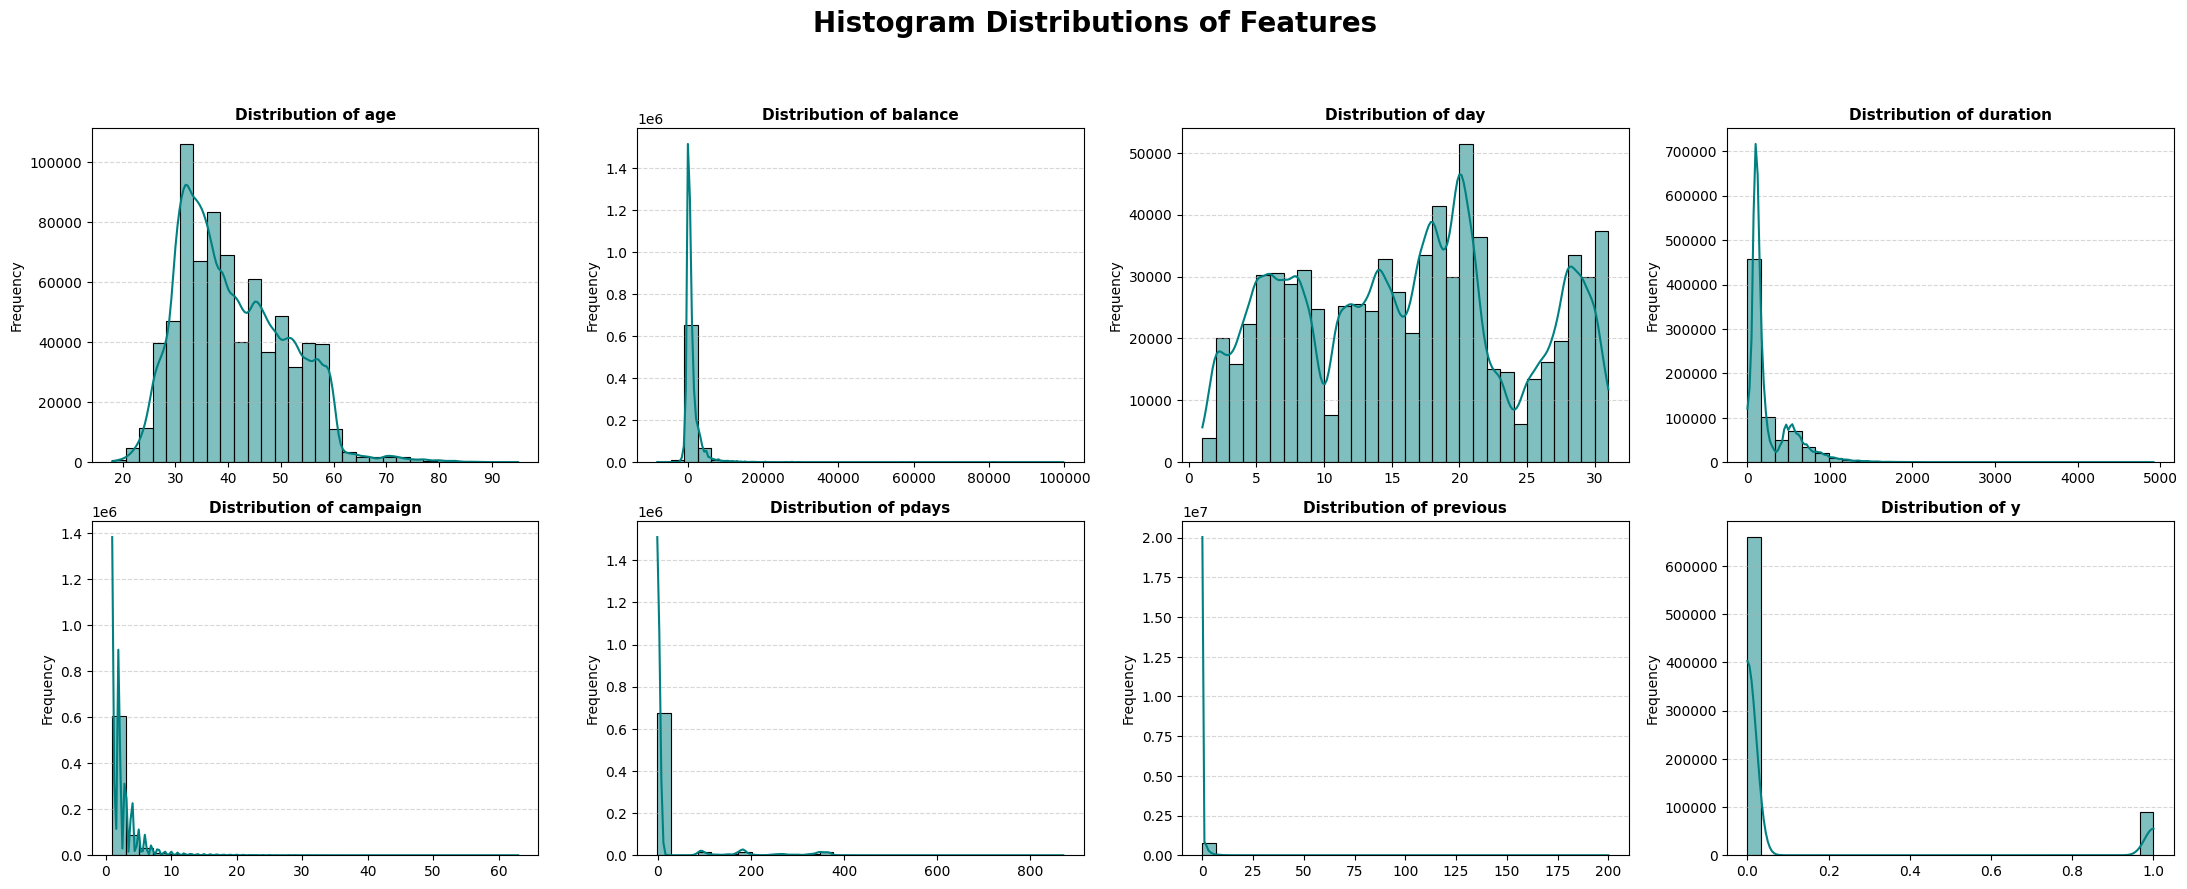

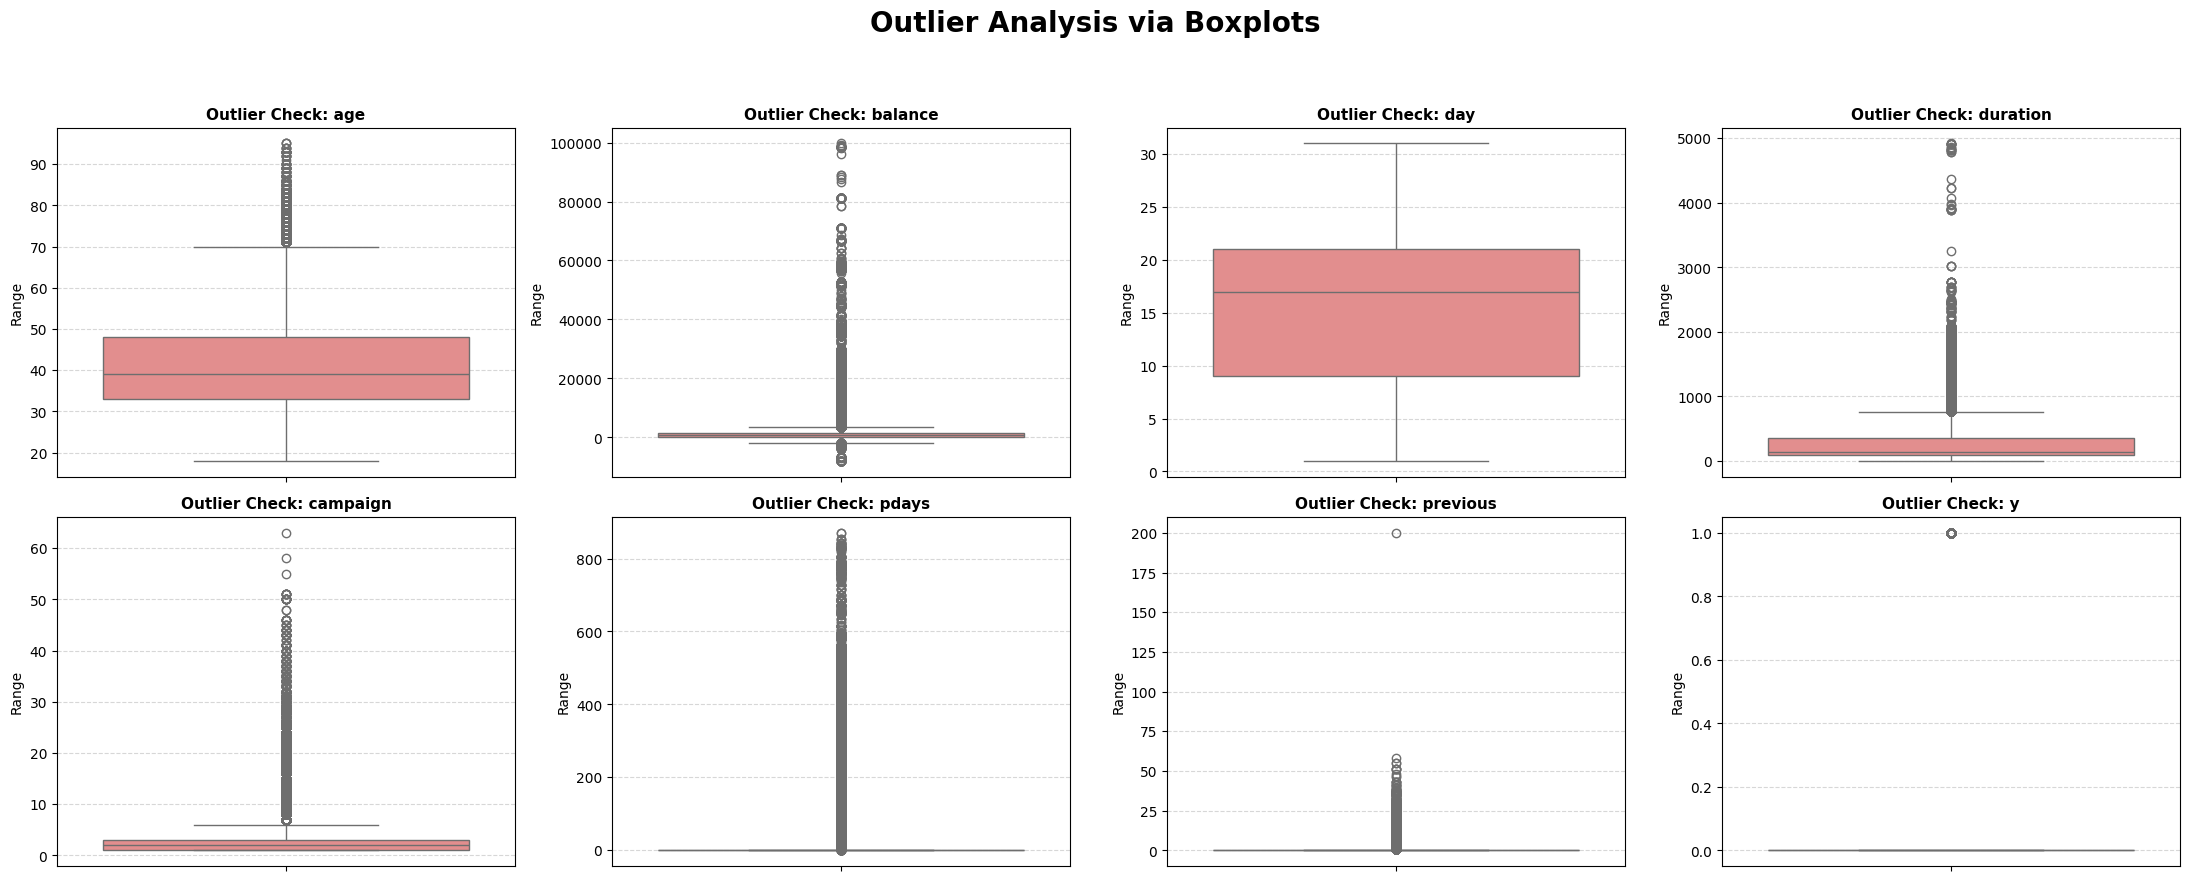

In [95]:
all_num_features = [col for col in train_df.select_dtypes(include=['int64', 'float64']).columns if col != 'id']

nrows = 5
ncols = 4

# Histogram
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 20))
axes = axes.flatten()

for i, col in enumerate(all_num_features):
    sns.histplot(train_df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histogram Distributions of Features', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Boxplot
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 20))
axes = axes.flatten()

for i, col in enumerate(all_num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outlier Analysis via Boxplots', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

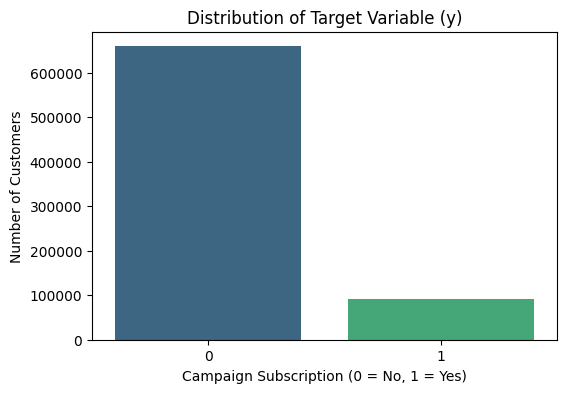

Target Variable (y) Percentages:
y
0    87.934933
1    12.065067
Name: proportion, dtype: float64


In [96]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='y', palette='viridis')
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Campaign Subscription (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

print("Target Variable (y) Percentages:")
print(train_df['y'].value_counts(normalize=True) * 100)

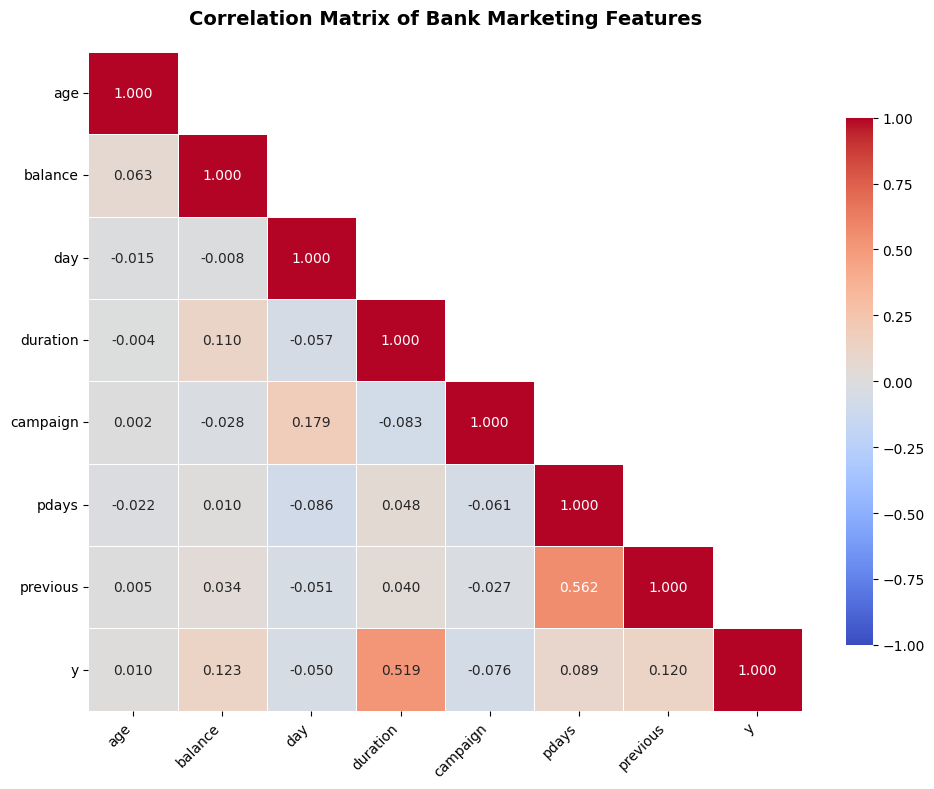

In [97]:
numerical_df = train_df.select_dtypes(include=['number']).drop(columns=['id', 'ID'], errors='ignore')

corr_matrix = numerical_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8} 
)

plt.title('Correlation Matrix of Bank Marketing Features', fontsize=14, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

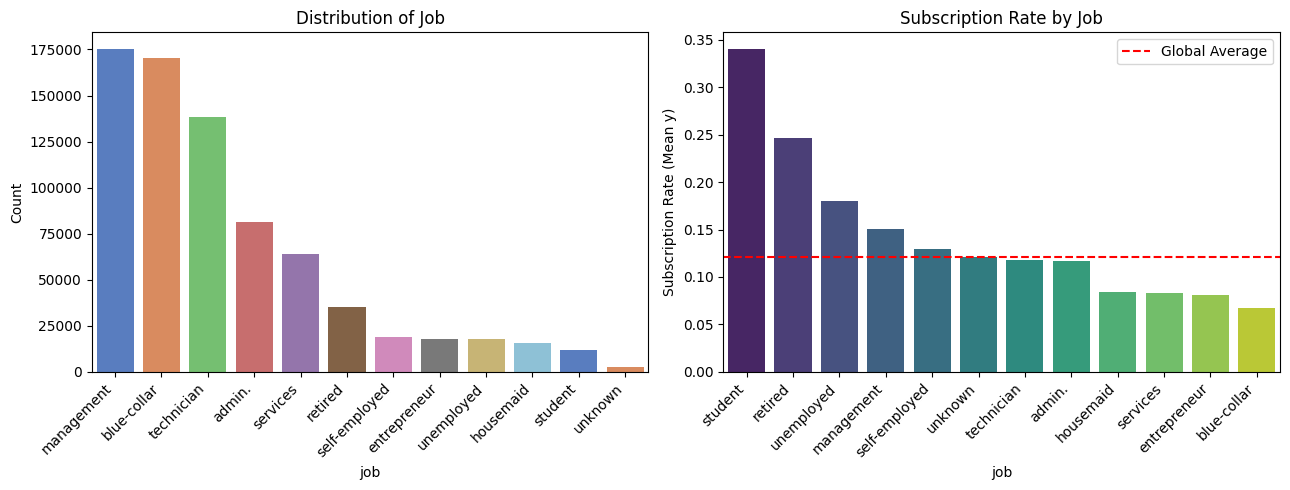

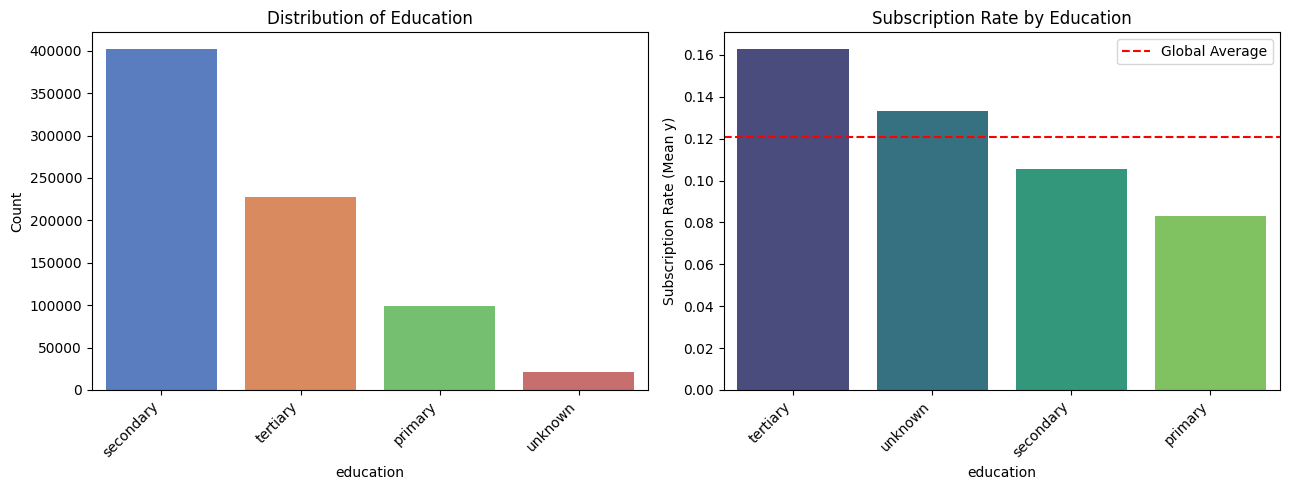

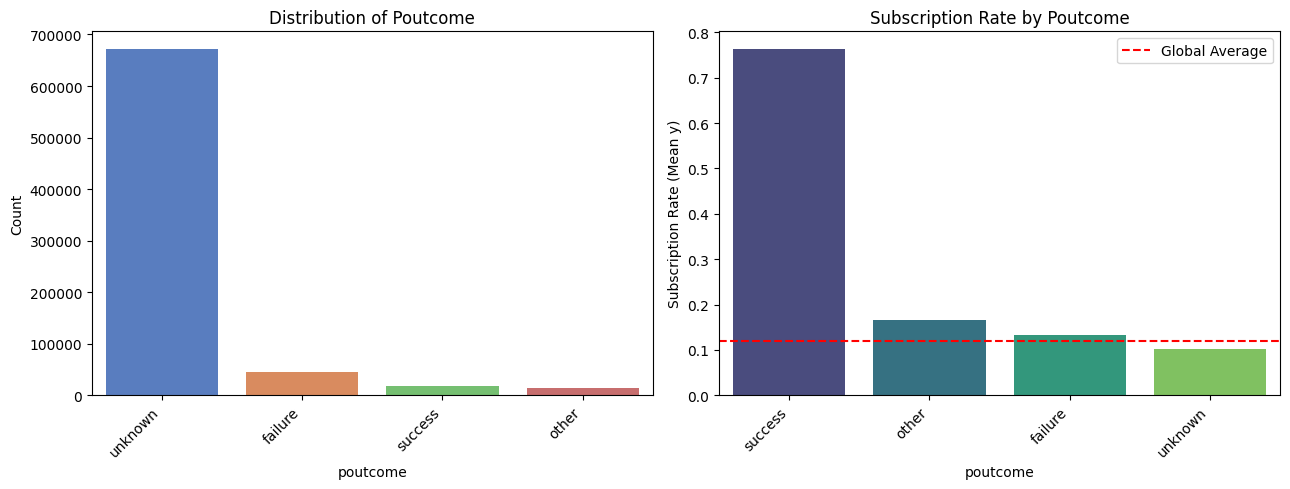

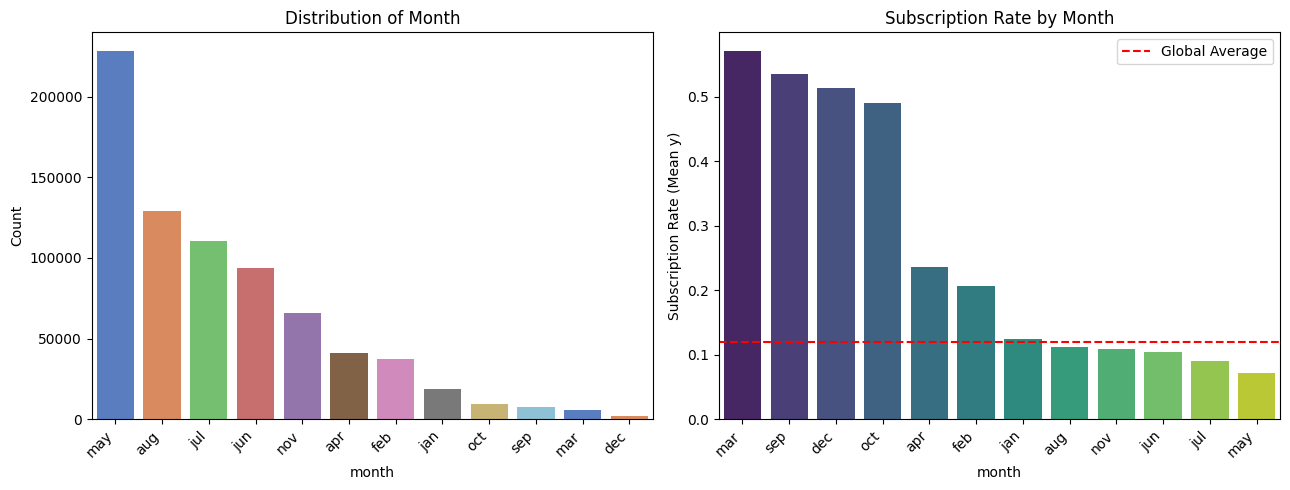

In [98]:
cat_features = ['job', 'education', 'poutcome', 'month']

for col in cat_features:
    plt.figure(figsize=(13, 5))
    
    plt.subplot(1, 2, 1)
    sns.countplot(data=train_df, x=col, palette='muted', order=train_df[col].value_counts().index)
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')
    
    plt.subplot(1, 2, 2)
    target_rate = train_df.groupby(col)['y'].mean().reset_index().sort_values(by='y', ascending=False)
    
    sns.barplot(data=target_rate, x=col, y='y', palette='viridis', order=target_rate[col])
    plt.axhline(y=train_df['y'].mean(), color='red', linestyle='--', label='Global Average')
    
    plt.title(f'Subscription Rate by {col.capitalize()}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Subscription Rate (Mean y)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

## 4. Data Preprocessing

In [99]:
x = train_df.drop(columns=['id', 'y'])
y = train_df['y']
x_test_final = test_df.drop(columns=['id'])

## 5. Model Training, Optimization & Deployment Strategy

In [100]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def algo_test(x, y):
    
    b = BernoulliNB()
    l = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
    d = DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42)
    r = RandomForestClassifier(n_estimators=100, max_samples=0.2, class_weight='balanced', n_jobs=-1, random_state=42)
    gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
    kn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ab = AdaBoostClassifier(random_state=42)
    svc = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
    xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42)
    lgb = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)

    models = [b, l, d, r, gb, kn, ab, svc, xgb, lgb]
    model_names = [
        "BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
        "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
        "AdaBoostClassifier", "LinearSVC", "XGBClassifier", "LGBMClassifier"
    ]

    x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
        x, y, test_size=0.20, random_state=42, stratify=y
    )
    
    num_cols = x_train_split.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
    scaler = StandardScaler()
    scaler.fit(x_train_split[num_cols])
    
    x_train_split[num_cols] = scaler.transform(x_train_split[num_cols])
    x_val_split[num_cols] = scaler.transform(x_val_split[num_cols])
    
    cat_cols = x_train_split.select_dtypes(include=['object']).columns.tolist()
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    
    x_train_split[cat_cols] = encoder.fit_transform(x_train_split[cat_cols])
    x_val_split[cat_cols] = encoder.transform(x_val_split[cat_cols])
    
    accuracy, precision, recall, f1 = [], [], [], []
    successful_models = []
    successful_names = []

    for model, name in zip(models, model_names):
        print(f"--> Training {name}...")
        try:
            model_fitted = model.fit(x_train_split, y_train_split)
            prediction = model_fitted.predict(x_val_split)
            
            accuracy.append(accuracy_score(y_val_split, prediction))
            precision.append(precision_score(y_val_split, prediction, zero_division=0))
            recall.append(recall_score(y_val_split, prediction, zero_division=0))
            f1.append(f1_score(y_val_split, prediction, zero_division=0))
            
            successful_models.append(model_fitted)
            successful_names.append(name)
            
        except Exception as e:
            print(f" [!] Error executing pipeline for {name}: {e}")
            continue

    metrics = pd.DataFrame(index=successful_names)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model_Object"] = successful_models

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("\n" + "="*50)
    best_model_name = metrics.index[0]
    print(f"TRUE MOST SUCCESSFUL MODEL BASED ON F1: {best_model_name}")
    print("="*50 + "\n")
    
    best_model_object = metrics.loc[best_model_name, "Model_Object"]
    final_prediction = best_model_object.predict(x_val_split)
    
    print(f"Real Confusion Matrix ({best_model_name}):")
    print(confusion_matrix(y_val_split, final_prediction))
    print(f"\nReal Classification Report ({best_model_name}):")
    print(classification_report(y_val_split, final_prediction))
    
    report_df = metrics.drop(columns=["Model_Object"])
    return report_df, metrics

In [101]:
report, full_metrics = algo_test(x, y)

--> Training BernoulliNB...
--> Training LogisticRegression...
--> Training DecisionTreeClassifier...
--> Training RandomForestClassifier...
--> Training GradientBoostingClassifier...
--> Training KNeighborsClassifier...
--> Training AdaBoostClassifier...
--> Training LinearSVC...
--> Training XGBClassifier...
--> Training LGBMClassifier...

TRUE MOST SUCCESSFUL MODEL BASED ON F1: RandomForestClassifier

Real Confusion Matrix (RandomForestClassifier):
[[128633   3269]
 [  7220  10878]]

Real Classification Report (RandomForestClassifier):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96    131902
           1       0.77      0.60      0.67     18098

    accuracy                           0.93    150000
   macro avg       0.86      0.79      0.82    150000
weighted avg       0.93      0.93      0.93    150000



In [102]:
report

,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.930073,0.768926,0.601061,0.674709
XGBClassifier,0.926193,0.748673,0.584484,0.656468
DecisionTreeClassifier,0.875867,0.492014,0.888496,0.633320
KNeighborsClassifier,0.916147,0.682467,0.570395,0.621418
LGBMClassifier,0.860400,0.461405,0.938667,0.618690
GradientBoostingClassifier,0.919427,0.730982,0.525638,0.611533
AdaBoostClassifier,0.915433,0.700289,0.522875,0.598716
LogisticRegression,0.859507,0.455914,0.850260,0.593558
LinearSVC,0.859567,0.455718,0.843574,0.591756
BernoulliNB,0.884347,0.529781,0.368604,0.434734


In [103]:
best_model_name = full_metrics.index[0]  # RandomForestClassifier
best_model_obj = full_metrics.loc[best_model_name, "Model_Object"]

In [104]:
x_train_raw, x_val_raw, y_train_raw, y_val_raw = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [105]:
num_cols = x_train_raw.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
scaler = StandardScaler()

In [106]:
scaler.fit(x_train_raw[num_cols])
x_val_raw[num_cols] = scaler.transform(x_val_raw[num_cols])

In [107]:
cat_cols = x_train_raw.select_dtypes(include=['object']).columns.tolist()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [108]:
encoder.fit(x_train_raw[cat_cols])
x_val_raw[cat_cols] = encoder.transform(x_val_raw[cat_cols])

In [109]:
y_pred = best_model_obj.predict(x_val_raw)
y_prob = best_model_obj.predict_proba(x_val_raw)[:, 1]

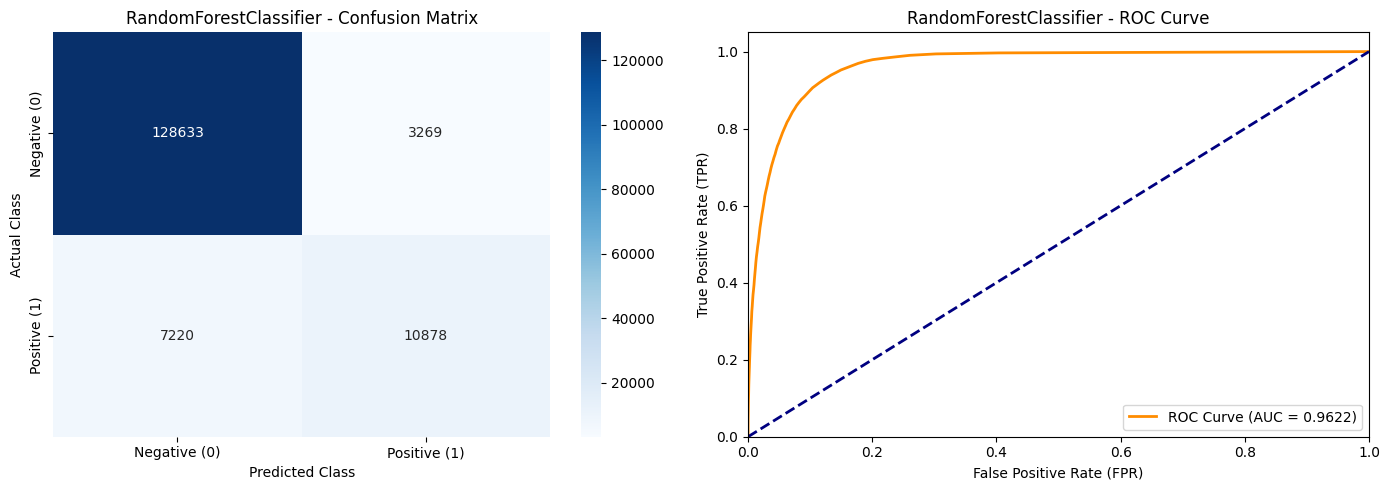

In [110]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# A. Confusion Matrix
cm = confusion_matrix(y_val_raw, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])
ax[0].set_title(f'{best_model_name} - Confusion Matrix')
ax[0].set_xlabel('Predicted Class')
ax[0].set_ylabel('Actual Class')

# B. ROC Curve
fpr, tpr, _ = roc_curve(y_val_raw, y_prob)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (FPR)')
ax[1].set_ylabel('True Positive Rate (TPR)')
ax[1].set_title(f'{best_model_name} - ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [111]:
x_train_final = train_df.drop(columns=['id', 'y'])
y_train_final = train_df['y']

In [112]:
test_ids = test_df['id']

In [113]:
x_test_final = test_df.drop(columns=['id'])

In [114]:
num_cols = x_train_final.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
scaler = StandardScaler()

In [115]:
scaler.fit(x_train_final[num_cols])

StandardScaler()

In [116]:
x_train_final[num_cols] = scaler.transform(x_train_final[num_cols])
x_test_final[num_cols] = scaler.transform(x_test_final[num_cols])

In [117]:
cat_cols = x_train_final.select_dtypes(include=['object']).columns.tolist()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [118]:
encoder.fit(x_train_final[cat_cols])

OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [119]:
x_train_final[cat_cols] = encoder.transform(x_train_final[cat_cols])
x_test_final[cat_cols] = encoder.transform(x_test_final[cat_cols])

In [120]:
final_model = RandomForestClassifier(
    n_estimators=100, 
    max_samples=0.2, 
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=42
)

In [121]:
final_model.fit(x_train_final, y_train_final)

RandomForestClassifier(class_weight='balanced', max_samples=0.2, n_jobs=-1,
                       random_state=42)

In [122]:
test_predictions = final_model.predict(x_test_final)

In [123]:
test_probabilities = final_model.predict_proba(x_test_final)[:, 1]

In [124]:
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'y': test_predictions
})

submission_df.to_csv('final_predictions.csv', index=False)

In [125]:
joblib.dump(final_model, 'bank_rf_model.joblib', compress=9)
joblib.dump(scaler, 'bank_scaler.joblib')
joblib.dump(encoder, 'bank_encoder.joblib')

['bank_encoder.joblib']

In [126]:
with open('bank_rf_model.pkl', 'wb') as model_file:
    pickle.dump(final_model, model_file)

with open('bank_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

with open('bank_encoder.pkl', 'wb') as encoder_file:
    pickle.dump(encoder, encoder_file)